In [522]:
import glob
import os

import pandas as pd
import numpy as np

import tifffile as tf
from tifffile import imread
from tifffile import imwrite

import skimage
from skimage.measure import label
from skimage.measure import label
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects
from skimage.morphology import remove_small_holes
from skimage.morphology import disk

from scipy.ndimage import binary_opening
from scipy.ndimage import binary_dilation
from scipy.ndimage import distance_transform_edt
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter


import matplotlib.pyplot as plt
import matplotlib

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [526]:
# Import images

actin_dir = '/Volumes/treutlein/DATA/imaging/Aileen/Automask/00_Batch20241005_iNs/D5/Unperturbed/Actin' # Max_projections
actin_path = os.path.join(actin_dir,'*.tif')
actin_files = np.sort(glob.glob(actin_path))

tubulin_dir = '/Volumes/treutlein/DATA/imaging/Aileen/Automask/00_Batch20241005_iNs/D5/Unperturbed/Tubulin' # Max_projections
tubulin_path = os.path.join(tubulin_dir,'*.tif')
tubulin_files = np.sort(glob.glob(tubulin_path))

cytoplasm_dir = '/Volumes/treutlein/DATA/imaging/Aileen/Automask/00_Batch20241005_iNs/D5/Unperturbed/Masks/All_labelled'
cytoplasm_path = os.path.join(cytoplasm_dir, '**', '*.tif')  # Use '**' to match subdirectories
cytoplasm_files = np.sort(glob.glob(cytoplasm_path, recursive=True))

nucleus_dir = '/Volumes/My Passport for Mac/Analysis/ACTB-KI/00_Batch20241005_iNs/D5/Unperturbed/ROIs/Nucleus'
nucleus_path = os.path.join(nucleus_dir,'*.tif')
nucleus_files = np.sort(glob.glob(nucleus_path))

In [503]:
#print(actin_files)
#print(tubulin_files)
#print(cytoplasm_files)

In [527]:
# Read images into list

actin_images = []

for file in actin_files:
    image = imread(file)
    actin_images.append(image)

tubulin_images = []

for file in tubulin_files:
    image = imread(file)
    tubulin_images.append(image)

cytoplasm_images = []

for file in cytoplasm_files:
    image = imread(file)
    cytoplasm_images.append(image)

nucleus_images = []

for file in nucleus_files:
    image = imread(file)
    nucleus_images.append(image)

In [528]:
print(len(actin_images))
print(len(tubulin_images))
print(len(cytoplasm_images))
print(len(nucleus_images))

28
28
28
28


#### Creating composite images of cytoskeleton and thresholding them to create masks

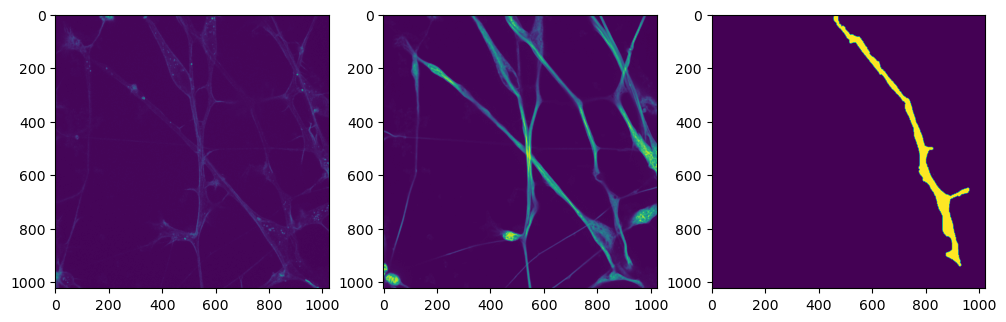

In [529]:
fig, ax = plt.subplots(1, 3, figsize = (12,4))
ax[0].imshow(actin_images[22])
ax[1].imshow(tubulin_images[22])
ax[2].imshow(cytoplasm_images[22])

In [530]:
# Merge actin and tubulin images

merged_images = []

for img1, img2 in zip(actin_images, tubulin_images):
    # Add images on top of each other
    merged_img = img1 + img2

    merged_images.append(merged_img)

print(len(merged_images))

28


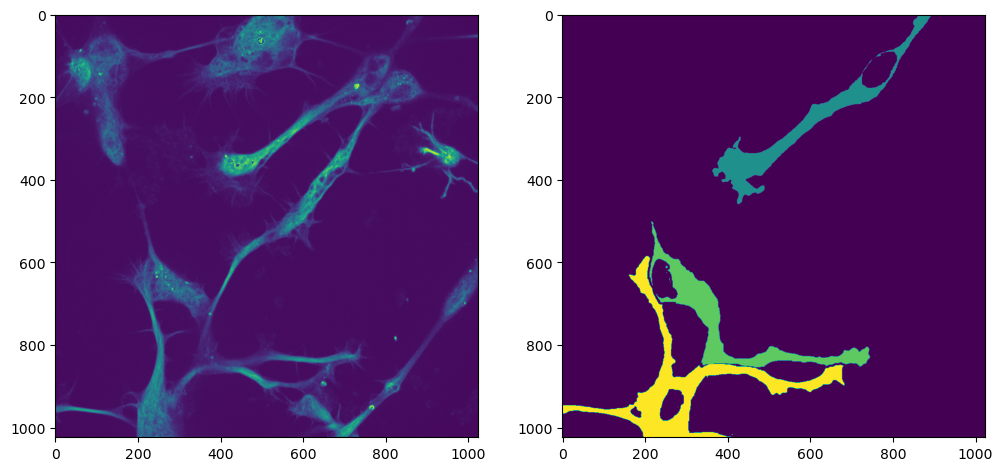

In [531]:
fig, ax = plt.subplots(1, 2, figsize = (12,6))
ax[0].imshow(merged_images[0])
ax[1].imshow(cytoplasm_images[0])

In [532]:
# Creates a stack and calculates the global otsu threshold which will be used to threshold all images

merged_stack = np.hstack(merged_images)
merged_otsu = threshold_otsu(merged_stack)*0.3 # Factor to adjust otsu
print(merged_otsu)

4087.2


In [533]:
# Segments merged_images based on merged_otsu

cytoskel_masks = []
for img in merged_images:
    mask = (img >= merged_otsu) # Binary mask
    #print(merged_otsu)
    cytoskel_masks.append(mask)

for i in range(len(cytoskel_masks)):
    mask_label = label(cytoskel_masks[i].astype(np.int64)) # Mask needs to be converted to integers for following operations
    cytoskel_masks[i] = remove_small_objects(mask_label, min_size=1000)  # Remove small objects
    cytoskel_masks[i] = (remove_small_holes(cytoskel_masks[i], area_threshold=2000) > 0)
    cytoskel_masks[i] = gaussian_filter(cytoskel_masks[i].astype(float), sigma=1.5) > 0.5 # Smoothen edges

/var/folders/x0/68qcnmdd17x84svtqbmr_7h40000gr/T/ipykernel_81525/2555403421.py:12: UserWarning: Any labeled images will be returned as a boolean array. Did you mean to use a boolean array?
  cytoskel_masks[i] = (remove_small_holes(cytoskel_masks[i], area_threshold=2000) > 0)


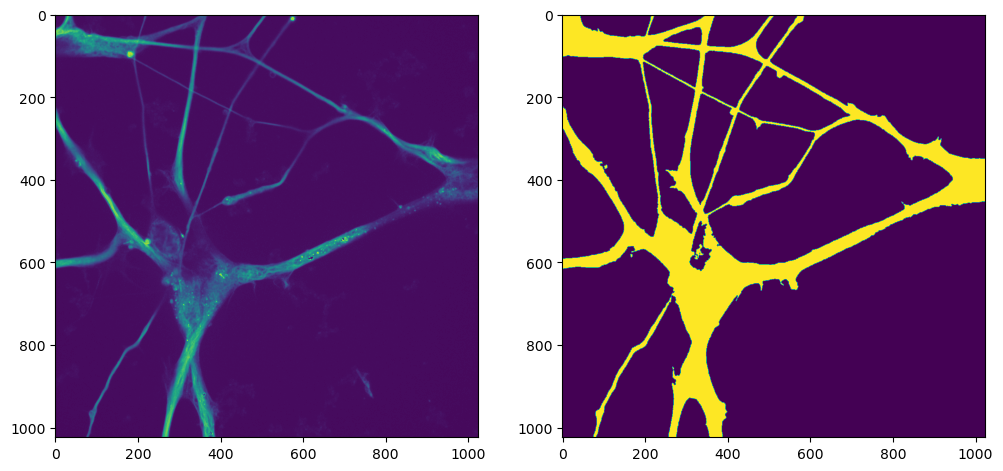

In [534]:
fig, ax = plt.subplots(1, 2, figsize = (12,6))
ax[0].imshow(merged_images[7])
ax[1].imshow(cytoskel_masks[7])

#### Using cytoskel_masks to identify "spikes"

In [535]:
# Creating spikes

masks_spikes = []

for image in cytoskel_masks:    
    opened_image = binary_opening(image, iterations=10) # Opens the image to smoothen out the spikes
    spikes = image ^ opened_image # Creates the spikes by substracting the opened image from the entire mask (boolean operator)


    # Refining spike mask by removing small objects and "large" objects, i.e. misidentified neurites
    refined_spikes = label(spikes.astype(np.int64))
    refined_spikes = remove_small_objects(refined_spikes, min_size=30)  # Remove small objects
    obj_trash = remove_small_objects(refined_spikes, min_size=500)  # Define large objects to remove in the next step
    refined_spikes = (refined_spikes ^ obj_trash) > 0 # Large objects are substracted from entire mask to leave only the spikes
    masks_spikes.append(refined_spikes)

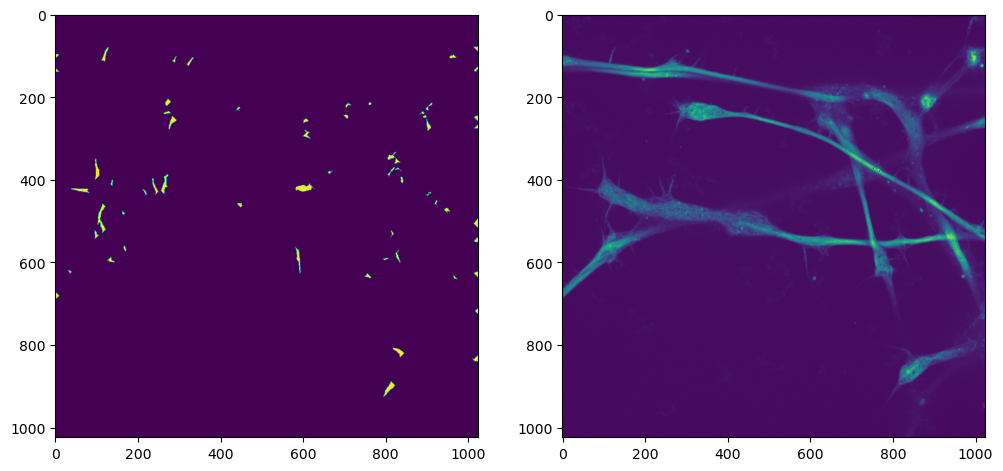

In [536]:
fig, ax = plt.subplots(1, 2, figsize = (12,6))
ax[0].imshow(masks_spikes[13])
ax[1].imshow(merged_images[13])

#### Merging cytoplasm mask with nucleus

In [537]:
# Adding nuclei back to cytplasm mask

whole_cells = []

for cyto_mask, nucleus_mask in zip(cytoplasm_images, nucleus_images):

    # Define maximum expansion in pixels
    max_expansion = 20  # Maximum expansion distance in pixels

    # Ensure masks have the same shape
    assert cyto_mask.shape == nucleus_mask.shape, "Masks must have the same dimensions"

    # Get unique nucleus labels
    nucleus_labels = np.unique(nucleus_mask)
    nucleus_labels = nucleus_labels[nucleus_labels > 0]  # Remove background (0)

    # Create a new expanded nucleus mask
    expanded_nucleus_mask = np.copy(nucleus_mask)

    for label_value in nucleus_labels:
        # Extract nucleus region
        nucleus_region = (nucleus_mask == label_value)
        
        # Extract corresponding cytoplasm region
        cyto_region = (cyto_mask == label_value)

        # Initialize dilation step
        dilation_step = 1
        expanded_region = nucleus_region.copy()  # Start with the original nucleus region
        
        while dilation_step <= max_expansion:
            # Apply dilation with a small disk (disk(1) to expand step by step)
            expanded_region = binary_dilation(expanded_region, disk(1))  # Expand by 1 pixel per step
            
            # Check if **all** of the expanded region touches the cytoplasm
            if np.all(expanded_region & cyto_region):  # Stop if ALL of the expanded region touches cytoplasm
                print(f"Expansion stopped at {dilation_step} pixels due to touching cytoplasm.")
                break  # Stop expanding when all of it touches the cytoplasm
            
            dilation_step += 1  # Increment the dilation step
        
        # Assign the expanded region to the output mask
        expanded_nucleus_mask[expanded_region] = label_value  # Update the expanded region in the mask

    # Merge the expanded nuclei with the cytoplasm mask
    whole_cell = np.where(expanded_nucleus_mask > 0, expanded_nucleus_mask, cyto_mask)
    whole_cells.append(whole_cell)

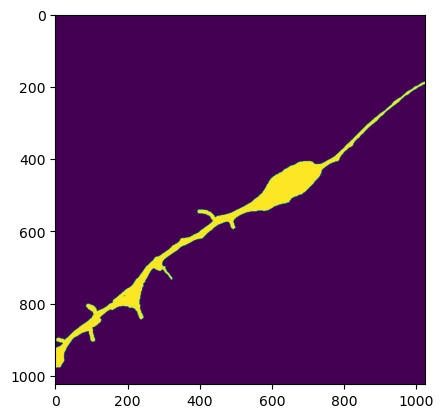

In [538]:
plt.imshow(whole_cells[-1])

#### Masking out cell body and neurites from cytoplasm_images (per ROI)

In [561]:
# Seperating cell masks into soma_outgrowth and neurite

neurites_mask_binary = []
soma_outgrowth_mask_binary = []

for cell_mask in whole_cells:

    # Get unique ROI labels from the mask
    roi_labels = np.unique(cell_mask)
    roi_labels = roi_labels[roi_labels > 0]  # Exclude the background (0)

    threshold_uniform = 8  # Distance threshold
    smoothed_distance_all_rois = []  # To store results for each ROI

    # Process each ROI individually
    for label_value in roi_labels:
        # Create a mask for the current ROI
        roi_mask = (cell_mask == label_value).astype(np.uint8)
        
        # Distance transform for the current ROI
        distance_transform_body = distance_transform_edt(roi_mask)
        smoothed_distance = uniform_filter(distance_transform_body, size=64) * roi_mask
        
        # Threshold to identify soma outgrowth
        soma_outgrowth = smoothed_distance > threshold_uniform
        soma_outgrowth = (binary_dilation(soma_outgrowth, iterations=15) * roi_mask) > 0  # Dilate to smooth out soma boundary
            
        # Identify neurites by thresholding the distance transform
        neurites = (np.logical_and((smoothed_distance > 0), (smoothed_distance < threshold_uniform)).astype(int) - soma_outgrowth.astype(int)) > 0
        
        # Label the neurites and remove small objects
        neurites = remove_small_objects(label(neurites.astype(int)), min_size=150) > 0
        
        # Store the result for this ROI
        smoothed_distance_all_rois.append((label_value, smoothed_distance, soma_outgrowth, neurites))

    # Combine the results back into one mask
    neurites_mask = np.zeros_like(cell_mask)  # Neurite outgrowth mask for all ROIs
    soma_outgrowth_mask = np.zeros_like(cell_mask)  # Soma outgrowth mask for all ROIs

    for label_value, smoothed_distance, soma_outgrowth, neurites in smoothed_distance_all_rois:
        neurites_mask[neurites] = label_value  # Assign each neurite to its corresponding label in the merged mask
        neurites_mask = neurites_mask > 0 # Binarize again

    neurites_mask_binary.append(neurites_mask)

    for label_value, smoothed_distance, soma_outgrowth, neurites in smoothed_distance_all_rois:
        soma_outgrowth_mask[soma_outgrowth] = label_value  # Assign each neurite to its corresponding label in the merged mask
        soma_outgrowth_mask = soma_outgrowth_mask > 0 # Binarize again

    soma_outgrowth_mask_binary.append(soma_outgrowth_mask)

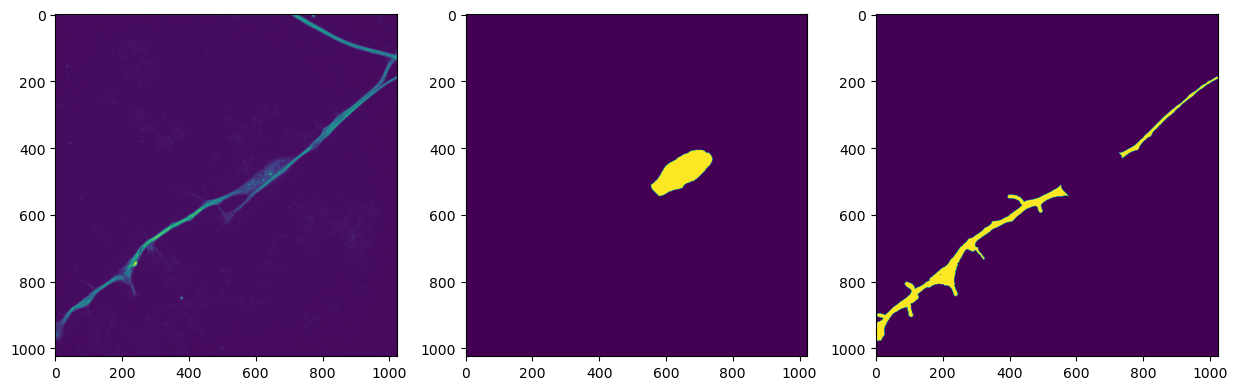

In [562]:
fig, ax = plt.subplots(1, 3, figsize = (15,8))
ax[0].imshow(merged_images[-1])
ax[1].imshow(soma_outgrowth_mask_binary[-1])
ax[2].imshow(neurites_mask_binary[-1])

In [563]:
# Complete labeled image

mask_compartments_prelim = []

for soma_outgrowth_final, neurite_final in zip(soma_outgrowth_mask_binary, neurites_mask_binary):
    # Create the initial mask with soma_outgrowth_mask_binary and neurites_mask_binary
    mask_compartment = soma_outgrowth_final + neurite_final * 2
    mask_compartments_prelim.append(mask_compartment)

mask_compartments = []

for prelim, spikes_final in zip(mask_compartments_prelim, masks_spikes):
    # Replace values where masks_spikes is present
    mask_compartment = np.where(spikes_final > 0, 3, prelim)
    mask_compartments.append(mask_compartment)


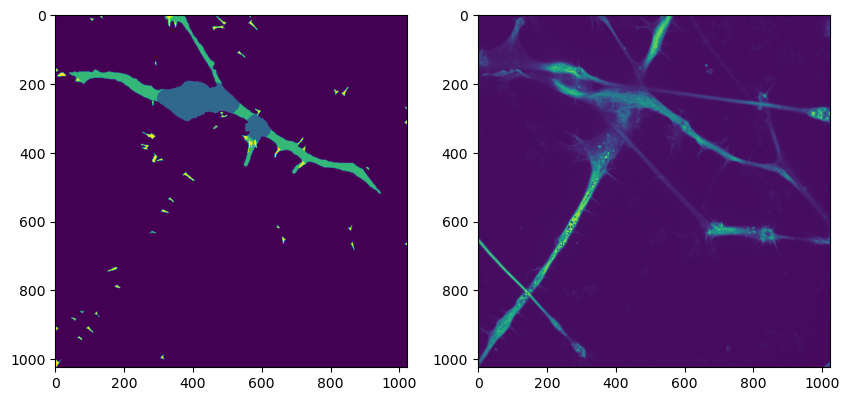

In [568]:
fig, ax = plt.subplots(1,2, figsize = (10, 8))
ax[0].imshow(mask_compartments[17])
ax[1].imshow(merged_images[17])

In [520]:
# Save cytoplasm masks

#output_dir = '/Volumes/bamfaile/Analysis/TUBB2B-KI/smFISH_organoids/D56/20240925_TUBB2B-KI_MCP-Halo-JF503_TUBB2B-565_MS2-633/Flipped/Max_projections'


In [ ]:
for img, tiff_file in zip(flipped_images, merged_files):
    
    # Extract the original file name without the extension
    file_name = os.path.splitext(os.path.basename(tiff_file))[0]
    print(file_name)
    
    # Define the output file path
    output_file = os.path.join(output_dir, file_name + '.tif')
    print(output_file)
    
    # Save the manipulated image as a TIFF
    tf.imwrite(output_file, img)